# Unsupervised Learning

Two methods were used:
1. The first of which was k-means clustering.
2. The second model was Gaussian mixture models, also known as GMM.

K-means clustering is a non-probabilistic model that focuses on doing centroid-based partitioning, while GMMs are probabilistic models and use a generative model.

These two models were selected because they work very differently from one another. K-means focuses on making distance-based calculations and assumes clusters of size that are pretty much equal, while GMMs focus on multivariate Gaussian predictions. What this means is we will be able to capture different types of methods and see which one would work better for our specific data set. 

In [76]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.impute import SimpleImputer


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


RANDOM_STATE = 42

## Data Loading

In [77]:
df_clean = pd.read_csv("/Users/indrayanbanerjee/Desktop/df_clean.csv")

## Preprocessing


Since all the features in the survey data are floats, before we start doing unsupervised learning, we must do six things. 

1. We must withhold the MedCost1 variable so that we can use it for validation after we finish the clustering process.
2. asthma3 already captures the asthma condition, so we can drop the asthnow variable.
3. We must recode the special codes in BRFSS, such as 7/9 meaning don't know or refused and 77/88/99 meaning the day count, as well as getting rid of the none variables and using the equivalent of them.
1. We have to make sure the binary variables are recoded, meaning yes would become 1 and no would become 2 so that we have proper indicators for the analyses.
2. Imputing the medians to make sure our analyses is thorough.
3. Making sure to standardize the variables tested so that when doing distance-based unsupervised learning, they aren't just dominated due to the scale of the features.


In [78]:

y = df_clean["MEDCOST1"].replace({1.0: 1, 2.0: 0, 7.0: np.nan, 9.0: np.nan})
df = df_clean.drop(columns=["MEDCOST1", "ASTHNOW"]).copy()


for var in ["PHYSHLTH", "MENTHLTH", "POORHLTH"]:
    df[var] = df[var].replace({88.0: 0.0, 77.0: np.nan, 99.0: np.nan})


binary_vars = [
    "VETERAN3", "CVDINFR4", "CVDCRHD4", "CVDSTRK3", "ASTHMA3",
    "CHCSCNC1", "CHCOCNC1", "CHCCOPD3", "ADDEPEV3", "CHCKDNY2",
    "EXERANY2", "SMOKE100"
]
for var in binary_vars:
    df[var] = df[var].replace({7.0: np.nan, 9.0: np.nan, 2.0: 0.0})


df["SEXVAR"] = df["SEXVAR"].replace({2.0: 0.0})

df["RMVTETH4"] = df["RMVTETH4"].replace({8.0: 0.0, 7.0: np.nan, 9.0: np.nan})


for var in ["MARITAL", "EDUCA", "RENTHOM1", "_RACEGR3", "INCOME3",
             "EMPLOY1", "PRIMINS2", "PERSDOC3", "CHECKUP1", "GENHLTH", "LASTDEN4"]:
    df[var] = df[var].replace({7.0: np.nan, 9.0: np.nan, 77.0: np.nan, 99.0: np.nan})


df["_BMI5"] = df["_BMI5"] / 100.0

print(df.isna().mean().sort_values(ascending=False).head(8))

INCOME3     0.445539
POORHLTH    0.426132
EMPLOY1     0.339367
PRIMINS2    0.104468
_BMI5       0.094035
SMOKE100    0.068766
PHYSHLTH    0.024181
RMVTETH4    0.020663
dtype: float64


In [79]:
imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()

X_imputed = imputer.fit_transform(df)
X_scaled  = scaler.fit_transform(X_imputed)

feature_names = df.columns.tolist()
print(X_scaled.shape)

(457670, 30)


## PCA 
In order to be able to compare K-Means and the GMM clusters with each other, two-component PCA will be used across all of the visuals. 

In [80]:
pca_visual = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca   = pca_visual.fit_transform(X_scaled)

var1 = pca_visual.explained_variance_ratio_[0]
var2 = pca_visual.explained_variance_ratio_[1]


print(f"PCA1: {var1}")
print(f"PCA2: {var2}")
print(f"total values: {var1+var2}")

PCA1: 0.12591207201151292
PCA2: 0.09821527555827071
total values: 0.22412734756978364


## 4. K-Means Clustering

### Why chosen:
K-Means algorithm works by partitioning values into groups and then assigning each record in the data to its nearest centroid and then recalculating each of the centroids. This type of algorithm is known as non-probabilistic and assumes that clusters have an equal amount of variance. After doing some research, I found that it works very well on large datasets, which is why I decided to make it our first choice for this type of data. 


### Hyperparameter Tuning
The number of clusters for K that was selected was done so by looking at:
1. The elbow method, which uses inertia versus the K number, and then identifies at which point returns start to diminish.
2. The silhouette score, which focuses on how similar each point in the data is to one another versus the cluster it's in and the cluster that's the second closest to it.



In [81]:
k_range   = range(2, 15)
inertiavals  = []
si_km_k  = []



for k in k_range:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)

    lbl = km.fit_predict(X_scaled)
    inertiavals.append(km.inertia_)

    si_km_k.append(silhouette_score(X_scaled, lbl, sample_size=15000, random_state=RANDOM_STATE))
    print(f"k={k}  inertia={km.inertia_}  silhouette={si_km_k[-1]}")

k=2  inertia=12589736.342070922  silhouette=0.20562580586268475
k=3  inertia=11781315.966922568  silhouette=0.10323032944524979
k=4  inertia=11337883.666962154  silhouette=0.10723873655010902
k=5  inertia=10931431.684240693  silhouette=0.09000977941792729
k=6  inertia=10567555.45333222  silhouette=0.08484012131757966
k=7  inertia=10242693.170283545  silhouette=0.07608674731670338
k=8  inertia=10016230.381097637  silhouette=0.07237459564703146
k=9  inertia=9763658.72346295  silhouette=0.07363322470113906
k=10  inertia=9568905.956621211  silhouette=0.06914314347516415
k=11  inertia=9439171.18972873  silhouette=0.0680241466342969
k=12  inertia=9303899.128437568  silhouette=0.038957170207063414
k=13  inertia=9089817.814791154  silhouette=0.04063250915947978
k=14  inertia=8912987.58014504  silhouette=0.0496004213119074


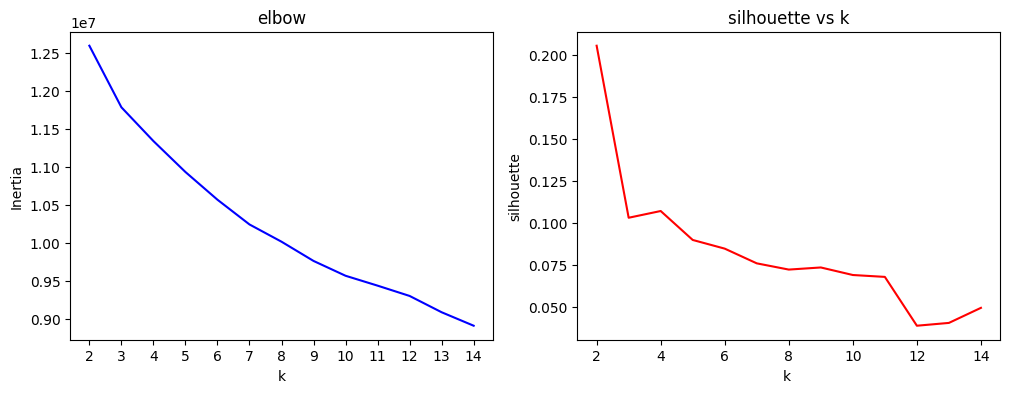

In [82]:
#Elbow and Silhouette Scores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertiavals,color="blue")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("elbow")
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), si_km_k, color="red")
axes[1].set_xlabel("k ")
axes[1].set_ylabel("silhouette")
axes[1].set_title("silhouette vs k")

plt.show()

In [83]:
best_knum = list(k_range)[int(np.argmax(si_km_k))]
print(f"best k number according to silhouette: {best_knum}")

km_best   = KMeans(n_clusters=best_knum, random_state=RANDOM_STATE, n_init=10)
km_labels = km_best.fit_predict(X_scaled)


sil_km = silhouette_score(X_scaled, km_labels, sample_size=15000, random_state=RANDOM_STATE)
db_km  = davies_bouldin_score(X_scaled, km_labels)
print(f"k means k={best_knum},   silhouette: {sil_km},   davies: {db_km}")
print(f"silhouette: {sil_km}")
print(f"davies: {db_km}")


print("cluster size:")
print(pd.Series(km_labels).value_counts().sort_index())

best k number according to silhouette: 2
k means k=2,   silhouette: 0.20562580586268475,   davies: 2.9572423337219518
silhouette: 0.20562580586268475
davies: 2.9572423337219518
cluster size:
0    101434
1    356236
Name: count, dtype: int64


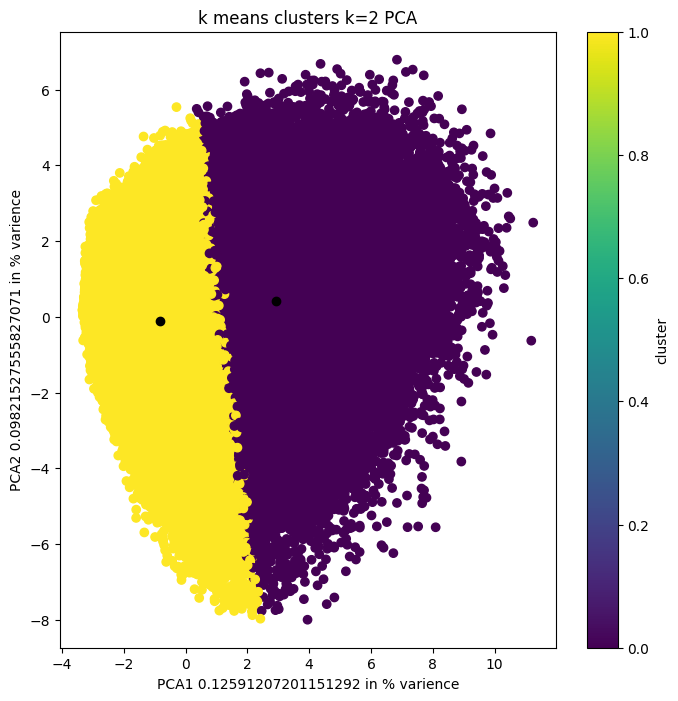

In [84]:
#Scatterplot for PCA
fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=km_labels
)

centroids_pca = pca_visual.transform(km_best.cluster_centers_)

ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c="black", label="centroids"
)

ax.set_xlabel(f"PCA1 {var1} in % varience")
ax.set_ylabel(f"PCA2 {var2} in % varience")
ax.set_title(f"k means clusters k={best_knum} PCA")
plt.colorbar(scatter, ax=ax, label="cluster")
plt.show()

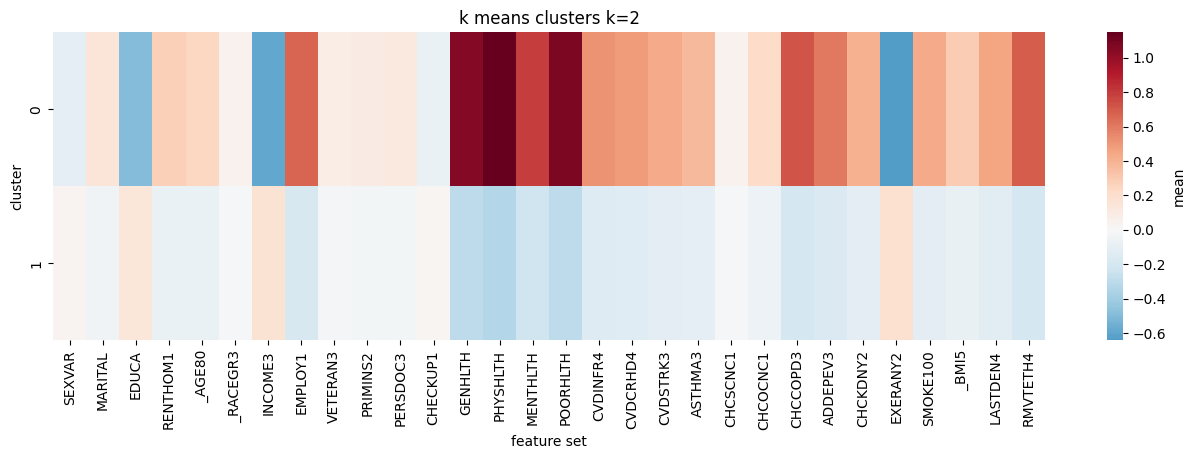

In [85]:
pro_df= pd.DataFrame(X_scaled, columns=feature_names)
pro_df["cluster"] = km_labels


cluster_means= pro_df.groupby("cluster").mean()

fig, ax = plt.subplots(figsize=(16, best_knum + 2))
sns.heatmap(
    cluster_means, cmap="RdBu_r", center=0, ax=ax,
    cbar_kws={"label": "mean"}
)


ax.set_title(f"k means clusters k={best_knum}")
ax.set_xlabel("feature set")
ax.set_ylabel("cluster")
plt.show()

## 5. Gaussian Mixture Models (GMM)

### Why chosen:
GMM models are based on multivariate Gaussian distributions. The other model we are using is K-Means, which focuses on hard assignments, while GMM focuses on soft assignments. What this helps do is allow GMM to capture more unique cases. The GMM model uses Expectation-Maximisation, which is different from K-Means's distance minimization formula. 

### Hyperparameter Tuning
In the model, the number of components that can be represented as N is selected using two methods:
1. BIC, which hurts the model complexity but is good for model selection
2. AIC, which hurts the model less and can be used alongside BIC to compare



In [86]:
n_range = range(2, 11)
bics    = []
aics    = []

for n in n_range:
    gmm = GaussianMixture(
        n_components=n, covariance_type="full",
        random_state=RANDOM_STATE, max_iter=300, n_init=3
    )
    
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))
    
    print(f"n={n}")
    print(f"BIC={bics[-1]}")
    print(f"AIC={aics[-1]}")

n=2
BIC=10796764.990227496
AIC=10785830.391681233
n=3
BIC=2134825.1837414475
AIC=2118417.7689702143
n=4
BIC=442318.19734363904
AIC=420437.9663474351
n=5
BIC=-3170192.6154905693
AIC=-3197545.662711744
n=6
BIC=-3378536.7243324504
AIC=-3411362.587778596
n=7
BIC=-6151718.815733451
AIC=-6190017.495404568
n=8
BIC=-7722745.545038837
AIC=-7766517.040934924
n=9
BIC=-8471544.757506821
AIC=-8520789.06962788
n=10
BIC=-11330560.007318987
AIC=-11385277.135665016


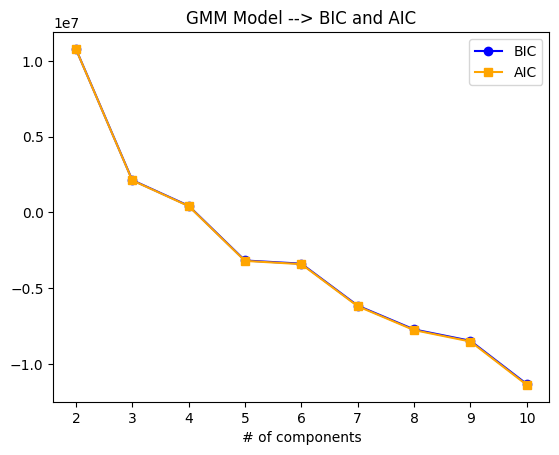

In [87]:
fig, ax = plt.subplots()
ax.plot(list(n_range), bics, marker="o", label="BIC", color="blue")
ax.plot(list(n_range), aics, marker="s", label="AIC", color="orange")


ax.set_xlabel("# of components")
ax.set_title("GMM Model --> BIC and AIC")


ax.set_xticks(list(n_range))
ax.legend()

plt.show()

In [88]:
best_num = list(n_range)[int(np.argmin(bics))]
print(f"n_components by BIC score: {best_num}")

gmm_best  = GaussianMixture(
    n_components=best_num, covariance_type="full",
    random_state=RANDOM_STATE, max_iter=300, n_init=3
)
gmm_best.fit(X_scaled)

gmm_labels = gmm_best.predict(X_scaled)
gmm_probs  = gmm_best.predict_proba(X_scaled)

sil_gmm = silhouette_score(X_scaled, gmm_labels, sample_size=15000, random_state=RANDOM_STATE)
db_gmm  = davies_bouldin_score(X_scaled, gmm_labels)
print(f"GMM (n={best_num})") 
print(f"Silhouette: {sil_gmm}")
print(f"Bouldin Score: {db_gmm:.4f}")


max_prob = gmm_probs.max(axis=1)
print(f"Avg assignment probability: {max_prob.mean():.3f}")
print(f"Percent of people with more than 90% certainty: {(max_prob > 0.9).mean():.1%}")

print("Component size:")
print(pd.Series(gmm_labels).value_counts().sort_index())

n_components by BIC score: 10
GMM (n=10)
Silhouette: 0.03573147080472642
Bouldin Score: 3.7580
Avg assignment probability: 0.999
Percent of people with more than 90% certainty: 99.7%
Component size:
0     31937
1    158697
2     13599
3     25497
4     84099
5     62248
6     24272
7      7359
8     23266
9     26696
Name: count, dtype: int64


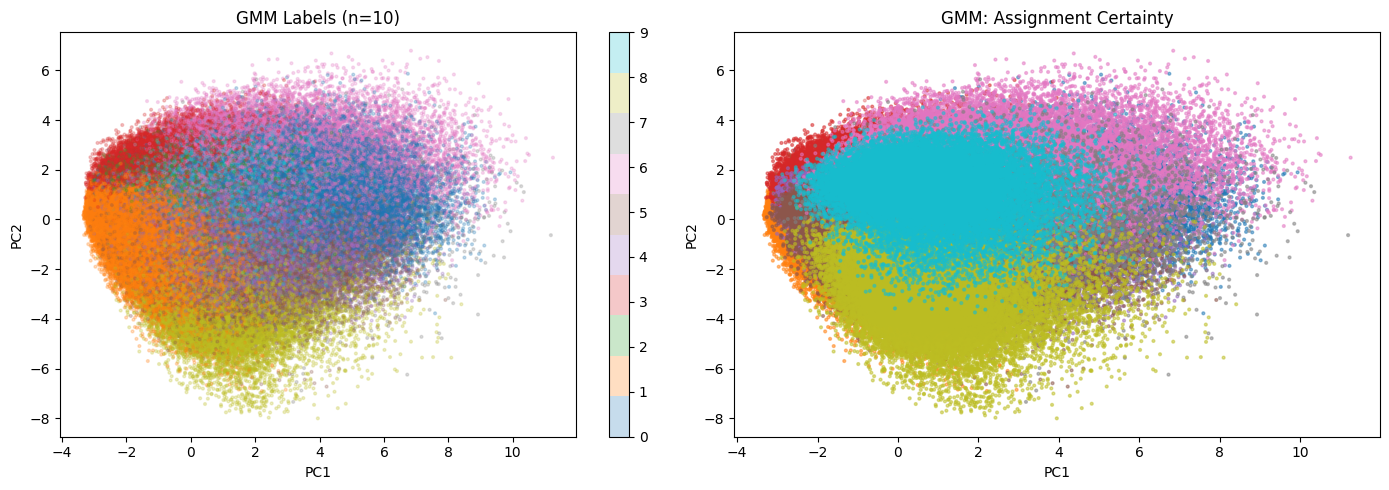

In [101]:
plt.close('all')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap="tab10", alpha=0.25, s=4)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title(f"GMM Labels (n={best_num})")
plt.colorbar(sc1, ax=axes[0])

alpha_vals = np.clip(max_prob, 0.05, 1.0)
for comp in range(best_num):
    mask = gmm_labels == comp
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=alpha_vals[mask] * 0.5, s=4)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("GMM: Assignment Certainty")

plt.tight_layout()
plt.show()


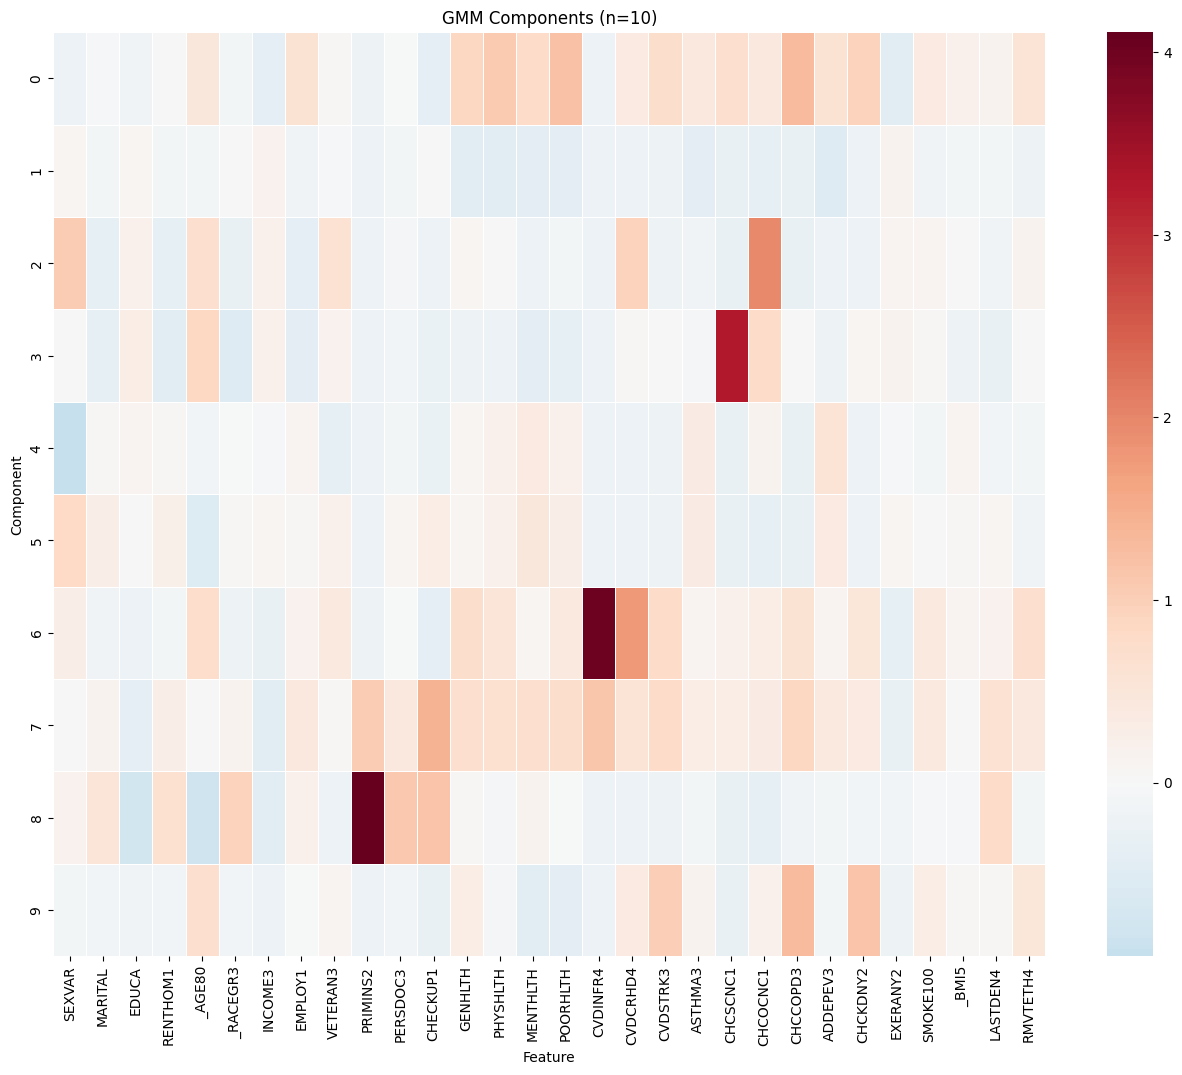

In [100]:
plt.close('all')

gmm_profile_df = pd.DataFrame(X_scaled, columns=feature_names)
gmm_profile_df["comp"] = gmm_labels
gmm_comp_means = gmm_profile_df.groupby("comp").mean()

plt.figure(figsize=(16, best_num + 2))
sns.heatmap(gmm_comp_means, cmap="RdBu_r", center=0, linewidths=0.4)
plt.title(f"GMM Components (n={best_num})")
plt.xlabel("Feature")
plt.ylabel("Component")
plt.show()


## 6. Model Comparison

### Metrics

Two metrics will be used to compare both of the models:
1. Silhouette score: In this, higher is better. It measures how close each point is to its own cluster versus the nearest other cluster. A score that's close to 1 means that they are well separated, while a score closer to 0 means there might be a case of overlapping clusters.
2. Bouldin index: in this, lower is better, and this measures a ratio of how data points are clustered within a cluster vs. the separation between clusters. A lower value would represent clusters that are close together and are separated from others pretty well. 

In [95]:
print("K-Means Results:")
print(f"k = {best_knum}")
print(f"Silhouette Score: {round(sil_km, 4)}")
print(f"Bouldin Score: {round(db_km, 4)}")

print("GMM Results:")
print(f"n = {best_num}")
print(f"Silhouette Score: {round(sil_gmm, 4)}")
print(f"Bouldin Score: {round(db_gmm, 4)}")


K-Means Results:
k = 2
Silhouette Score: 0.2056
Bouldin Score: 2.9572
GMM Results:
n = 10
Silhouette Score: 0.0357
Bouldin Score: 3.758


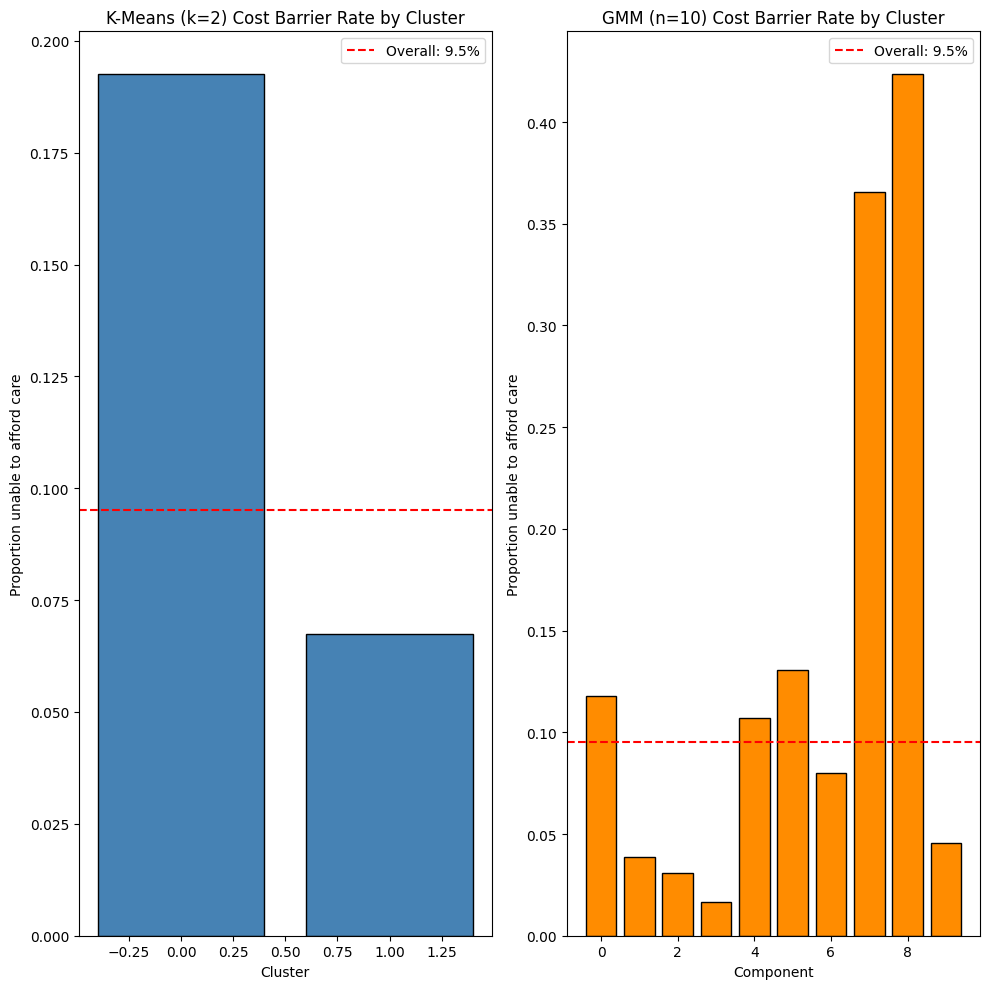

In [99]:
valid_mask = y.notna().values
y_valid = y[valid_mask].values
overall = y_valid.mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 10))

km_df = pd.DataFrame({"cluster": km_labels[valid_mask], "cost": y_valid})
km_cost_rate = km_df.groupby("cluster")["cost"].mean().sort_index()
axes[0].bar(km_cost_rate.index, km_cost_rate.values, color="steelblue", edgecolor="black")
axes[0].axhline(overall, linestyle="--", color="red", label=f"Overall: {overall:.1%}")
axes[0].set_title(f"K-Means (k={best_knum}) Cost Barrier Rate by Cluster")
axes[0].set_ylabel("Proportion unable to afford care")
axes[0].set_xlabel("Cluster")
axes[0].legend()


gmm_df = pd.DataFrame({"cluster": gmm_labels[valid_mask], "cost": y_valid})
gmm_cost_rate = gmm_df.groupby("cluster")["cost"].mean().sort_index()
axes[1].bar(gmm_cost_rate.index, gmm_cost_rate.values, color="darkorange", edgecolor="black")
axes[1].axhline(overall, linestyle="--", color="red", label=f"Overall: {overall:.1%}")
axes[1].set_title(f"GMM (n={best_num}) Cost Barrier Rate by Cluster")
axes[1].set_ylabel("Proportion unable to afford care")
axes[1].set_xlabel("Component")
axes[1].legend()

plt.tight_layout()
plt.show()


## Sensitivity Analysis 

We can measure the sensitivity of the KMeans model we just trained by looking at two different things:
1. We will focus on random seed sensitivity. What this shows is silhouette scores across five different random seeds that we tested for each.
2. Feature sensitivity compares the silhouette scores across all of the features we have, and then also looks at the socioeconomic features and, lastly, chronic condition features. This helps us see what features might affect the clusters the most.

In [112]:
seeds = [0, 7, 42, 99, 123]

sens_rows = []
for k in range(2, 9):
    for seed in seeds:
        lbl = KMeans(n_clusters=k, random_state=seed, n_init=5).fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, lbl, sample_size=10000, random_state=42)
        db = davies_bouldin_score(X_scaled, lbl)
        sens_rows.append({"k": k, "seed": seed, "silhouette": sil, "bouldin": db})

sens_df = pd.DataFrame(sens_rows)
print(sens_df.groupby("k")["silhouette"].agg(["mean", "std", "min", "max"]).round(4))
\
print(sens_df.groupby("k")["bouldin"].agg(["mean", "std", "min", "max"]).round(4))


     mean     std     min     max
k                                
2  0.2064  0.0004  0.2058  0.2067
3  0.1050  0.0001  0.1049  0.1052
4  0.1017  0.0098  0.0903  0.1089
5  0.0840  0.0154  0.0633  0.1049
6  0.0798  0.0107  0.0676  0.0908
7  0.0788  0.0113  0.0715  0.0986
8  0.0643  0.0189  0.0309  0.0769
     mean     std     min     max
k                                
2  2.9607  0.0039  2.9572  2.9668
3  2.7469  0.0003  2.7463  2.7473
4  2.8019  0.1811  2.6695  3.0036
5  2.7453  0.1623  2.5558  2.9310
6  2.6701  0.1165  2.5533  2.8148
7  2.5822  0.1013  2.4013  2.6327
8  2.6116  0.0588  2.5473  2.6946


In [113]:
feature_groups = {
    "All features": feature_names,
    "Socioeconomic & access": ["INCOME3", "EMPLOY1", "EDUCA", "PRIMINS2", "PERSDOC3",
                                "CHECKUP1", "RENTHOM1", "VETERAN3", "MARITAL"],
    "Chronic conditions": ["CVDINFR4", "CVDCRHD4", "CVDSTRK3", "ASTHMA3", "CHCSCNC1",
                           "CHCOCNC1", "CHCCOPD3", "ADDEPEV3", "CHCKDNY2"],
}

feat_sil = {}
for group_name, cols in feature_groups.items():
    idx = [feature_names.index(c) for c in cols if c in feature_names]
    Xsub = X_scaled[:, idx]
    lbl = KMeans(n_clusters=best_knum, random_state=RANDOM_STATE, n_init=10).fit_predict(Xsub)
    sil = silhouette_score(Xsub, lbl, sample_size=10000, random_state=RANDOM_STATE)
    feat_sil[group_name] = sil
    print(group_name)
    print("silhouette:", round(sil, 4))


All features
silhouette: 0.2067
Socioeconomic & access
silhouette: 0.26
Chronic conditions
silhouette: 0.5393


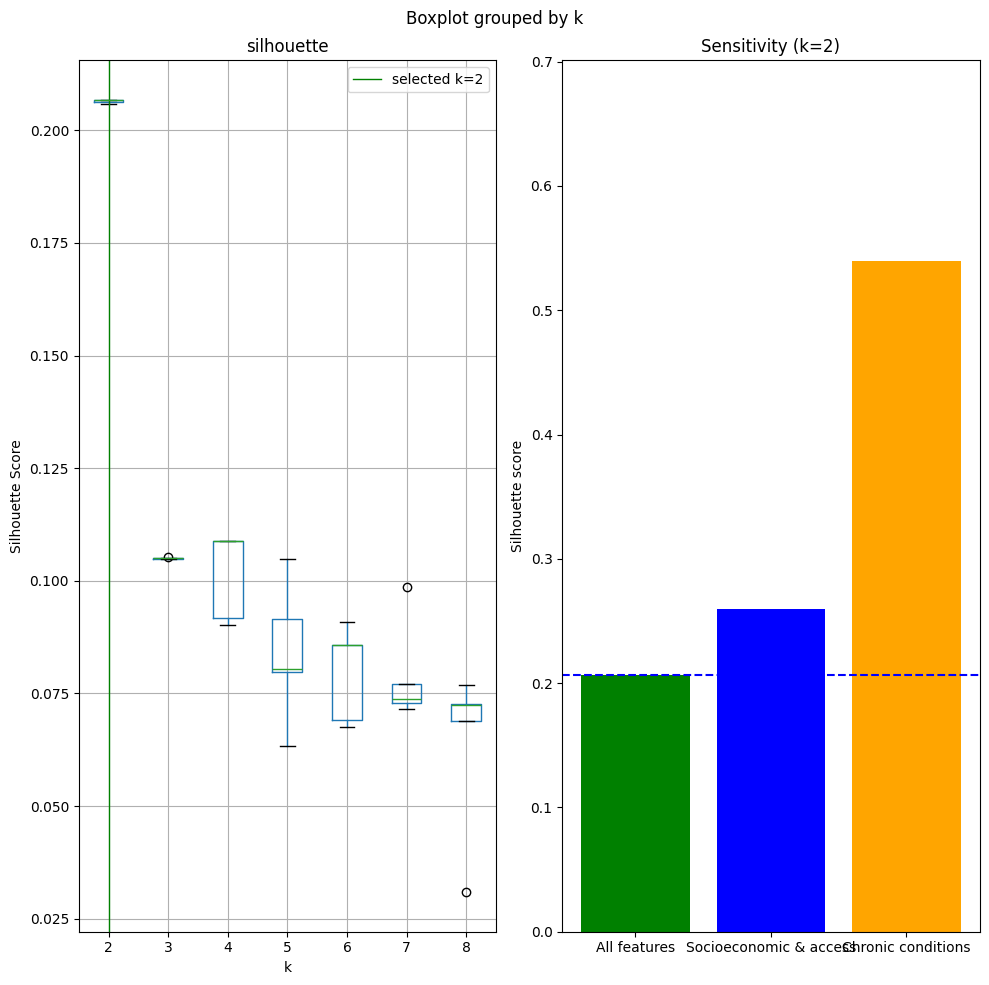

In [115]:
plt.close('all')

fig, axes = plt.subplots(1, 2, figsize=(10, 10))

sens_df.boxplot(column="silhouette", by="k", ax=axes[0])
axes[0].axvline(
    x=list(range(2, 9)).index(best_knum) + 1,
    color="green", linewidth=1, label=f"selected k={best_knum}"
)
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette Score")
axes[0].legend()

axes[1].bar(feat_sil.keys(), feat_sil.values(), color=["green", "blue", "orange"])
axes[1].axhline(feat_sil["All features"], color="blue", linestyle="--")
axes[1].set_ylabel("Silhouette score")


axes[1].set_title(f"Sensitivity (k={best_knum})")
axes[1].set_ylim(0, max(feat_sil.values()) * 1.3)

plt.tight_layout()
plt.show()
